<center><h1>HW2</h1></center>
<br>
<br>

Name: XIAOMAN NIU
<br>
USC ID: 6306697960
<br>
Github: xiaomann339

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
!pip install openpyxl
!pip install statsmodels

Get the Cycle Power Plant Data Set

In [2]:
import os
print(os.getcwd())

/Users/non-sense/Desktop/DSCI552/hw2/notebook


In [3]:
df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [4]:
df.shape

print("rows:", df.shape[0])
print("columns:", df.shape[1])

rows: 9568
columns: 5


**The row represents**  hourly observation of the power plant operating at full load.

**The columns represent** four input features and one outcome variable:

- **AT**: Ambient Temperature
- **V**: Exhaust Vacuum
- **AP**: Ambient Pressure
- **RH**: Relative Humidity
- **PE**: Net hourly electrical energy output **(the response variable)**

#### ii. pairwise scatterplots of all the varianbles

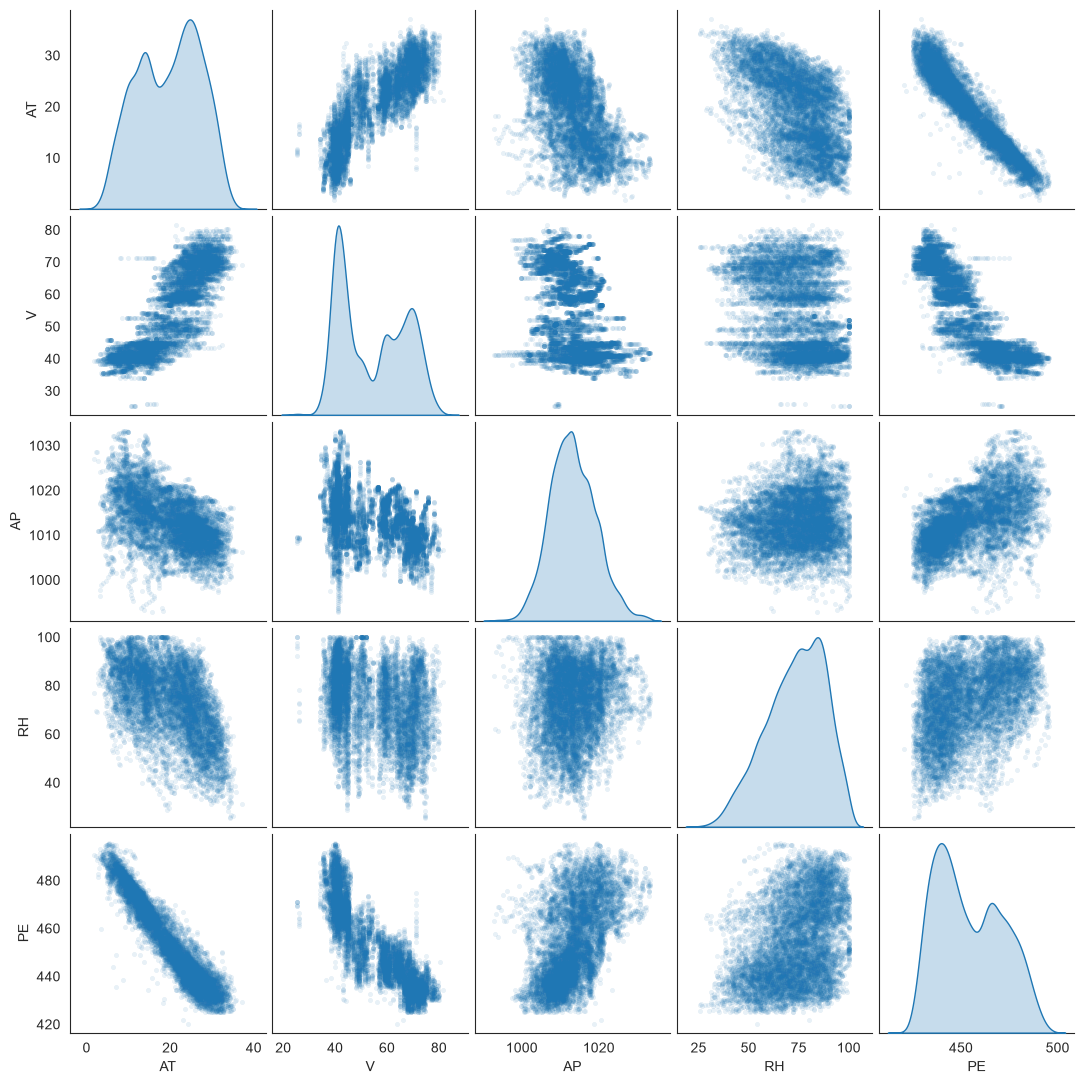

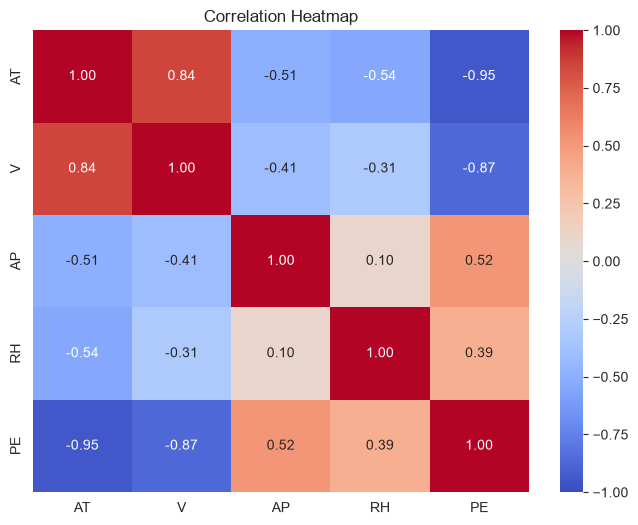

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
sns.pairplot(data = df, vars = ["AT", "V", "AP", "RH", "PE"], plot_kws={'alpha': 0.1, 's': 10, 'edgecolor': None},
    diag_kind='kde',
    height=2.2)

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

##### **Findings**

##### Distribution of Individual Variables

- **AT, V, and PE** each exhibit a bimodal distribution, with two distinct peaks.
- **AP** follows an approximately bell-shaped (normal-like) distribution.
- **RH** is left-skewed, with a long tail extending toward lower values.


##### Relationships Between Independent Variables and the Dependent Variable (PE)

- **AT and PE**: Show a strong negative relationship, with a fairly linear pattern across the full range of AT.
- **V and PE**: Also show a negative relationship, but the pattern is not uniformly linear across the entire range. Most points follow a clear primary trend (PE decreasing as V increases), which appears roughly linear in the higher-V region. However, in the lower-V region (around V ≈ 40), a subset of points shows noticeably elevated PE values (approximately 480–495), diverging from the main trend. This suggests the relationship may not be globally linear and could reflect two distinct operating regimes rather than a single continuous curve.

##### Relationships Among Independent Variables

- **AT and V**: Show a fairly strong positive relationship.
- **AT and RH**: Show a moderate negative relationship.
- No other strong pairwise relationships are visually apparent among the remaining predictor combinations.


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [6]:
df.describe()

df.max()
df.min()
df.quantile(0.75)
df.quantile(0.25)
range_data = df.max() - df.min()
IQR = df.quantile(0.75) - df.quantile(0.25)

data_summary = pd.concat([df.mean(), df.median(), range_data, df.quantile(0.25), df.quantile(0.75), IQR], axis=1)
data_summary.columns = ['Mean', 'Median', 'Range', 'Q1', 'Q3', 'IQR']
data_summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [7]:
# fit model of each single predictor

import statsmodels.api as sm

predictors = ["AT", "V", "AP", "RH"]
y = df["PE"]
results_dict = {}

for predictor in predictors:
    X = df[[predictor]]
    X = sm.add_constant(X)

    results = sm.OLS(y, X).fit()

    results_dict[predictor] = results # for further detection(eg. outliers) for each model

    print(f"\nRegression model: PE ~ {predictor}")
    print(results.summary())


Regression model: PE ~ AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:23   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341    

In [8]:
# summary key infomation of each single predictor model

predictors = ["AT", "V", "AP", "RH"]
regression_results = []

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df["PE"]

    results = sm.OLS(y, X).fit()
    confidence_interval = results.conf_int().loc[predictor]

    regression_results.append({
        "Predictor": predictor,
        "Intercept": results.params["const"],
        "Coefficient": results.params[predictor],
        "P-value": results.pvalues[predictor],
        "R-squared": results.rsquared,
        "CI Lower": confidence_interval.iloc[0],
        "CI Upper": confidence_interval.iloc[1]
    })

results_df = pd.DataFrame(regression_results)
results_df

,Predictor,Intercept,Coefficient,P-value,R-squared,CI Lower,CI Upper
0,AT,497.034120,-2.171320,0.0,0.898948,-2.185910,-2.156730
1,V,517.801526,-1.168135,0.0,0.756518,-1.181417,-1.154853
2,AP,-1055.260989,1.489872,0.0,0.268769,1.440620,1.539124
3,RH,420.961766,0.455650,0.0,0.151939,0.434075,0.477225


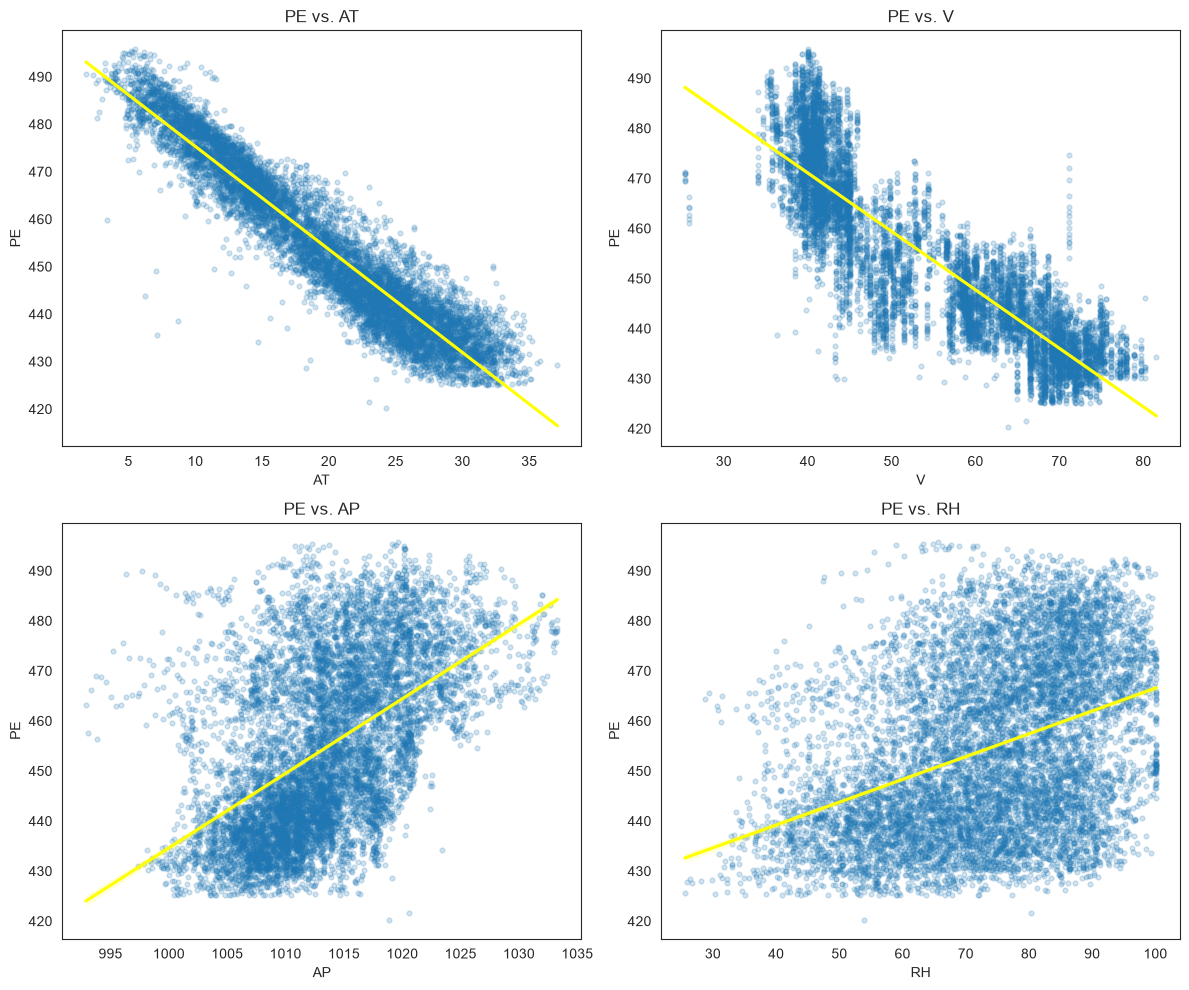

In [9]:
# scatterplot 

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        ax=ax,
        scatter_kws={"alpha": 0.2, "s": 12},
        line_kws={"color": "yellow"},
    )

    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()


##### **Simple Linear Regression — Results Summary & analysis**

A simple linear regression model was fit for each of the four predictors 
(AT, V, AP, RH) individually to predict PE. The summary table above shows 
the fitted coefficients, R², and p-values for all four models.

**Statistical significance**: All four predictors have p-values below 0.001
(well below the 0.05 threshold), so there is a statistically significant 
association between PE and every individual predictor — we reject 
H0: β1 = 0 in all four cases.

**Strength and direction of the relationships**: The predictors differ 
substantially in how much of PE's variance they explain individually:

- **AT** shows the strongest relationship (R² = 0.899), with a negative 
  coefficient (β1 = -2.17): each 1°C increase in ambient temperature is 
  associated with an average decrease of about 2.17 MW in power output.
- **V** also shows a strong negative relationship (R² = 0.757, β1 = -1.17).
- **AP** and **RH** show weaker, though still statistically significant, 
  positive relationships (R² = 0.269 and 0.152 respectively).

The large sample size (n = 9,568) means that even the comparatively weak 
relationships (e.g., RH) are detected as statistically significant — 
statistical significance here should be interpreted alongside R² to judge 
practical importance, rather than relied upon alone.

The direction of each relationship is consistent with the correlations 
identified in the exploratory analysis in part (b): AT and V are 
negatively associated with PE, while AP and RH are positively associated 
with PE. Scatterplots with fitted regression lines for each predictor 
(shown above) visually confirm these relationships, with AT showing the 
tightest, most linear fit and RH showing the most scattered relationship.

In [10]:
# find outliers（using Standardized Residuals (3-sigma rule)）

at_results = results_dict["AT"]
standardized_resid = at_results.resid / at_results.resid.std()
outliers_AT = df[standardized_resid.abs() > 3]
print(f"number of outlier points: {len(outliers_AT)}")

v_results = results_dict["V"]
standardized_resid = v_results.resid / v_results.resid.std()
outliers_V = df[standardized_resid.abs() > 3]
print(f"number of outlier points: {len(outliers_V)}")

ap_results = results_dict["AP"]
standardized_resid = ap_results.resid / ap_results.resid.std()
outliers_AP = df[standardized_resid.abs() > 3]
print(f"number of outlier points: {len(outliers_AP)}")

rh_results = results_dict["RH"]
standardized_resid = rh_results.resid / rh_results.resid.std()
outliers_RH = df[standardized_resid.abs() > 3]
print(f"number of outlier points: {len(outliers_RH)}")

number of outlier points: 42
number of outlier points: 33
number of outlier points: 28
number of outlier points: 2


In [11]:
# find outliers （using interquartile range (IQR) method)-- Flag a point as an outlier if it falls outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

for name in ["AT", "V", "AP", "RH"]:
    resid = results_dict[name].resid
    Q1 = resid.quantile(0.25)
    Q3 = resid.quantile(0.75)
    IQR = Q3 - Q1
    
    outliers_iqr = df[(resid < Q1 - 1.5*IQR) | (resid > Q3 + 1.5*IQR)]
    print(f"{name} - Number of outliers using IQR: {len(outliers_iqr)}")

AT - Number of outliers using IQR: 70
V - Number of outliers using IQR: 140
AP - Number of outliers using IQR: 63
RH - Number of outliers using IQR: 0


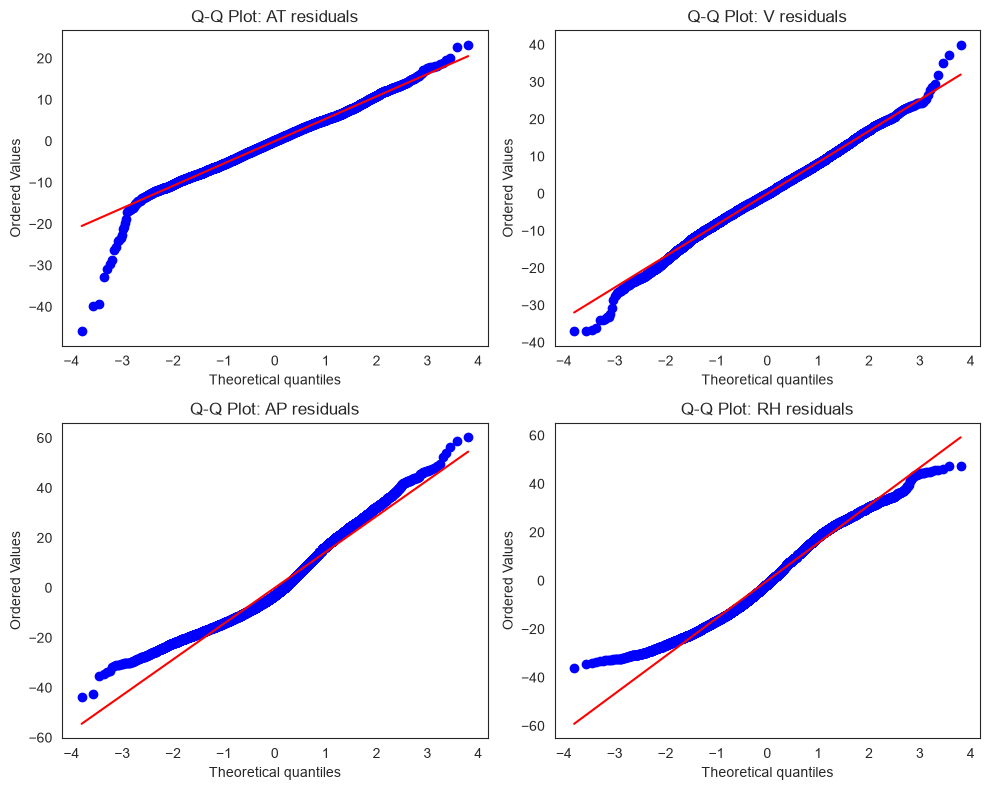

In [12]:
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, name in zip(axes.flatten(), ["AT", "V", "AP", "RH"]):
    stats.probplot(results_dict[name].resid, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {name} residuals")
plt.tight_layout()
plt.show()

##### **Outlier Assessment for Simple Linear Regression Models**

Potential outliers were assessed using two methods: standardized 
residuals (3-sigma rule) and the interquartile range (IQR / Tukey's 
fences) method.

| Model | 3-sigma method | IQR method |
|---|---|---|
| AT | 42 | 70 |
| V | 33 | 140 |
| AP | 28 | 63 |
| RH | 2 | 0 |

The two methods give noticeably different counts across all four models. 
This is likely because the 3-sigma rule assumes approximately normal 
residuals, while the IQR method does not. Q-Q plots of the residuals 
confirm that none of the four models' residuals are perfectly normal — 
all show deviation from the reference line at the tails, with RH showing 
the most pronounced deviation and AT the least, consistent with the 
significant Jarque-Bera test results reported in each model's summary. 
This suggests the 3-sigma method's outlier counts should be interpreted 
with some caution, and the IQR method may offer a more robust estimate.

Even under the higher IQR-based counts, flagged points represent a small 
share of the data (at most ~1.5% of 9,568 observations, for V). Given 
this small proportion, and that the choice of detection method 
meaningfully changes the results, no points were removed from any model. 
Removing them would also require re-fitting and re-validating every 
model, adding complexity without a clear, method-independent justification 
for which points are "true" outliers. Instead, these results are 
presented as a caveat: outlier counts are sensitive to the method used, 
and conclusions from the weaker-fitting models (AP, RH in particular) 
should be interpreted with this in mind.

### (d) Multiple Regression

In [13]:
X = df[["AT", "V", "AP", "RH"]]
X = sm.add_constant(X)

multi_result = sm.OLS(y, X).fit()
print(multi_result.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

#####  **Multiple Regression Results**

A multiple linear regression model was fit using all four predictors:

**PE = 454.61 − 1.98·AT − 0.23·V + 0.06·AP − 0.16·RH**

**Model fit**: R² = 0.929 — higher than any single predictor from part (c), 
including AT alone (R² = 0.899). The overall F-test is highly significant 
(p ≈ 0.00).

**Significance of predictors**: All four predictors have p-values below 0.001, 
so we reject H0: βj = 0 for **all four** — AT, V, AP, and RH are each 
significantly associated with PE, even after controlling for the others.

**Comparison with simple regression**: Although all predictors remain 
significant, several coefficients shrank considerably compared to their 
simple regression values, and RH's coefficient **reversed sign** (from 
+0.46 to −0.16). This is consistent with multicollinearity among the 
predictors — notably the strong AT–V correlation (r = 0.84) and moderate 
AT–RH correlation (r = −0.54) seen in part (b). Once AT's effect is held 
constant, RH's independent association with PE points in the opposite 
direction from its raw correlation.


In [14]:
#VIF test

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[["AT", "V", "AP", "RH"]]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data

,Variable,VIF
0,const,1.000000
1,AT,5.977602
2,V,3.943003
3,AP,1.452639
4,RH,1.705290


While the model flags a large condition number (2.13e+05), 
condition number alone can be inflated by differences in variable scale 
(e.g., AP's larger numeric range) and does not by itself confirm 
multicollinearity. VIF values provide more direct evidence: AT (VIF = 
5.98) and V (VIF = 3.94) show moderate multicollinearity — consistent 
with their strong pairwise correlation (r = 0.84) — while AP (VIF = 
1.45) and RH (VIF = 1.71) show little evidence of collinearity with the 
other predictors.

### (e) 1c Compare to 1d

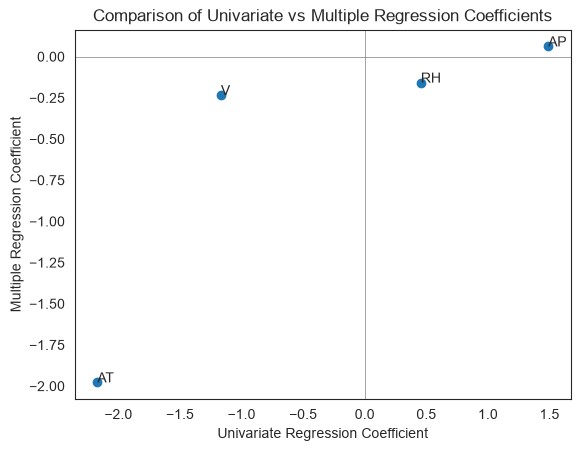

In [15]:
predictors = ["AT", "V", "AP", "RH"]

uni_coefs = [results_dict[p].params[p] for p in predictors]
multi_coefs = [multi_result.params[p] for p in predictors]

plt.scatter(uni_coefs, multi_coefs)

for i, p in enumerate(predictors):
    plt.annotate(p, (uni_coefs[i], multi_coefs[i]))


plt.xlabel("Univariate Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Comparison of Univariate vs Multiple Regression Coefficients")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()


##### **Comparison of Simple vs. Multiple Regression Coefficients**

**AT**: Coordinates approximately (−2.17, −1.98) — nearly on the y = x 
line. AT's coefficient is essentially unchanged between the simple and 
multiple regression settings, suggesting its relationship with PE is 
largely independent of the other predictors.

**V**: Coordinates approximately (−1.17, −0.23) — still in the same 
(negative) direction, but the coefficient shrinks to roughly a fifth of 
its simple-regression size once the other predictors are included. This 
suggests that much of V's apparent effect on PE may be tied up with its 
correlation with AT, rather than reflecting an independent contribution.

**AP and RH**: These two predictors show the largest shifts. AP's 
coefficient drops from about +1.49 to nearly 0 (+0.06), and **RH's 
coefficient reverses sign entirely**, from +0.46 in the simple regression 
to −0.16 in the multiple regression — the only predictor to cross the 
zero line.


The plot suggests that the predictors are not equally robust to the 
inclusion of other variables in the model. AT's coefficient stays close 
to the y = x line, indicating its association with PE is relatively 
stable regardless of which other predictors are included. V, AP, and 
especially RH, on the other hand, show substantial shrinkage in 
coefficient magnitude, and RH's coefficient flips sign altogether. This 
pattern is consistent with — though not definitive proof of — the 
multicollinearity identified in part (b), particularly the strong AT–V 
correlation (r = 0.84) and the moderate AT–RH correlation (r = −0.54). 
A plausible interpretation is that once AT's effect is accounted for, 
some of what looked like an independent relationship between V, AP, RH 
and PE in the simple regressions may instead be partly explained by 
their correlation with AT, rather than representing a fully independent 
effect. 

### (f) Nonlinear Association

In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly_results= {}

for predictor in predictors:
    X_raw = df[[predictor]]
    poly = PolynomialFeatures(degree = 3, include_bias = False)
    X_poly = poly.fit_transform(X_raw)
    X_poly = sm.add_constant(X_poly)
    poly_results[predictor] = sm.OLS(y, X_poly).fit()

    print(f"\nPolynomial model: PE ~ {predictor} + {predictor}^2 + {predictor}^3")
    print(poly_results[predictor].summary())


Polynomial model: PE ~ AT + AT^2 + AT^3
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

/var/folders/1b/dx4mrxhx1d53v09vmyyq_k640000gn/T/ipykernel_65125/2903865224.py:10: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  poly_results[predictor] = sm.OLS(y, X_poly).fit()


##### **Centered version** 
predictors mean-centered before generating polynomial terms, to address the numerical instability observed above.

In [17]:
#Re-fitting with mean-centered predictors to address the numerical instability above

poly_results_centered = {}

for predictor in predictors:
    X_raw = df[[predictor]] - df[[predictor]].mean()
    
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(X_raw)
    X_poly = sm.add_constant(X_poly)
    
    poly_results_centered[predictor] = sm.OLS(y, X_poly).fit()
    
    print(f"\n[Centered] Polynomial model: PE ~ {predictor} + {predictor}^2 + {predictor}^3")
    print(poly_results_centered[predictor].summary())


[Centered] Polynomial model: PE ~ AT + AT^2 + AT^3
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


##### **Nonlinear Association**

##### **Initial Results (Without Preprocessing)**

For each predictor, a cubic polynomial model 
(Y = β0 + β1X + β2X² + β3X³) was fit using `PolynomialFeatures` to 
generate the higher-order terms, and the significance of the X² and X³ 
coefficients was used to assess evidence of nonlinearity.

Fitting directly on the raw predictor values produced the following:

| Predictor | x² p-value | x³ p-value |
|---|---|---|
| AT | < 0.001 | < 0.001 |
| V | 0.768 | 0.014 |
| AP | < 0.001 | < 0.001 |
| RH | < 0.001 | < 0.001 |

##### **Problem Identified**

Alongside these results, `statsmodels` reported extremely large condition 
numbers (ranging from 1.9e+05 to 2.12e+15), and the AT model triggered a 
rank-deficiency warning. This type of issue typically arises when a 
predictor does not vary around zero, causing the raw X, X², and X³ terms 
to be highly collinear with one another, which in turn makes the matrix 
computations numerically unstable and the resulting coefficient estimates 
potentially unreliable.

##### **Adjustment Made**

To address this, each predictor was mean-centered before generating the 
polynomial terms. After centering, the condition numbers dropped by 2 to 
12 orders of magnitude across all four models, indicating substantially 
improved numerical stability.

##### **Results After Centering**

| Predictor | x² p-value | x³ p-value |
|---|---|---|
| AT | < 0.001 | < 0.001 |
| V | < 0.001 | 0.014 |
| AP | < 0.001 | < 0.001 |
| RH | 0.101 | < 0.001 |

Comparing the two sets of results, the significance of the quadratic term 
for V and RH shifted in opposite directions before and after centering 
(V: non-significant → significant; RH: significant → non-significant). 
This inconsistency suggests that the uncentered results may have been 
affected by numerical instability, so the centered results are used as 
the basis for the analysis that follows.


In [18]:
#joint test

print("Joint test of H0: β2 = β3 = 0 (nonlinear terms)")
print("-" * 50)

for predictor in predictors:
    result = poly_results_centered[predictor]
    nonlinear_test = result.f_test("x2 = 0, x3 = 0")
    print(f"{predictor}: F = {nonlinear_test.fvalue:.2f}, p-value = {nonlinear_test.pvalue:.3e}")

Joint test of H0: β2 = β3 = 0 (nonlinear terms)
--------------------------------------------------
AT: F = 701.97, p-value = 3.478e-285
V: F = 393.31, p-value = 7.040e-165
AP: F = 195.89, p-value = 4.209e-84
RH: F = 10.19, p-value = 3.800e-05


##### **Joint Significance Test for Nonlinear Terms**

Rather than relying solely on the individual p-values of the quadratic 
and cubic terms — which can be ambiguous when the two terms are 
correlated with each other, as seen for RH — a joint F-test of 
H0: β2 = β3 = 0 was conducted for each predictor using the 
mean-centered polynomial models.

| Predictor | F-statistic | p-value | Conclusion |
|---|---|---|---|
| AT | 701.97 | 3.48×10⁻²⁸⁵ | Significant nonlinearity |
| V | 393.31 | 7.04×10⁻¹⁶⁵ | Significant nonlinearity |
| AP | 195.89 | 4.21×10⁻⁸⁴ | Significant nonlinearity |
| RH | 10.19 | 3.80×10⁻⁵ | Significant nonlinearity |

All four predictors show statistically significant evidence of a 
nonlinear relationship with PE. For RH, although the quadratic term 
alone was not individually significant, the joint test confirms that 
the quadratic and cubic terms together do improve the model 
significantly — the earlier individually-mixed result (quadratic 
non-significant, cubic significant) does not rule out nonlinearity 
overall. Notably, RH's F-statistic (10.19) is substantially smaller 
than the other three predictors' (195–700), consistent with its 
weaker overall model fit (R² = 0.154) — the nonlinear effect for RH, 
while statistically real, appears considerably weaker in practical 
terms than for AT, V, or AP. As given the large sample size (n = 
9,568), even modest deviations from linearity can register as highly 
significant, so these results should be read as evidence of the 
*presence* of nonlinearity rather than a claim about its practical 
magnitude.

### (g) Interactions of Predictors

In [19]:
X_raw = df[["AT", "V", "AP", "RH"]]

poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interact = poly_interact.fit_transform(X_raw)

X_interact = sm.add_constant(X_interact)
interaction_results = sm.OLS(y, X_interact).fit()
print(interaction_results.summary())
poly_interact.get_feature_names_out(["AT","V","AP","RH"])

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

array(['AT', 'V', 'AP', 'RH', 'AT V', 'AT AP', 'AT RH', 'V AP', 'V RH',
       'AP RH'], dtype=object)

In [20]:
# mean-centered predictors 
# Centering addresses the large condition number seen above 

X_raw = df[["AT", "V", "AP", "RH"]] - df[["AT", "V", "AP", "RH"]].mean()

poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interact = poly_interact.fit_transform(X_raw)

X_interact = sm.add_constant(X_interact)
interaction_results_centered = sm.OLS(y, X_interact).fit()
print(interaction_results_centered.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        452.6946      0.075   6074.393      0.0

##### **Interaction Effects Summary**

A full regression model with all six pairwise interaction terms 
(AT×V, AT×AP, AT×RH, V×AP, V×RH, AP×RH) was fit. Results were verified 
using both raw and mean-centered predictors — the significance of all six 
interaction terms was identical across both versions (condition number 
improved from 1.7e+08 to 390 after centering, with no change in p-values), 
confirming the findings are numerically robust.

**Results**:

| Interaction | p-value | Significant? |
|---|---|---|
| AT × V | < 0.001 | Yes |
| AT × RH | < 0.001 | Yes |
| V × AP | < 0.001 | Yes |
| AP × RH | 0.034 | Borderline — significant but close to the threshold |
| V × RH | 0.086 | No |
| AT × AP | 0.452 | No |

**Conclusion**: There is evidence of interaction effects, but not across 
all predictor pairs. AT×V, AT×RH, and V×AP show clear, strong evidence of 
interaction. AP×RH is only marginally significant and, given the large 
sample size, should be interpreted cautiously rather than treated as 
strong evidence. AT×AP and V×RH show no evidence of interaction.

### (h) Improvement

In [21]:
from sklearn.model_selection import train_test_split

X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

print(f"size of training set: {X_train.shape[0]}")
print(f"size of test set: {X_test.shape[0]}")

X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test)

model1 = sm.OLS(y_train, X_train_c).fit() #as baseline model

y_train_pred1 = model1.predict(X_train_c)
y_test_pred1 = model1.predict(X_test_c)

from sklearn.metrics import mean_squared_error

train_mse1 = mean_squared_error(y_train, y_train_pred1)
test_mse1 = mean_squared_error(y_test, y_test_pred1)

print(f"Model 1 - Train MSE: {train_mse1:.4f}")
print(f"Model 1 - Test MSE: {test_mse1:.4f}")


# construct model with interaction terms and quadratic nonlinearities

poly_full = PolynomialFeatures(degree = 2, include_bias = False)

X_train_poly = poly_full.fit_transform(X_train)
X_test_poly = poly_full.transform(X_test)

feature_names = poly_full.get_feature_names_out(X_train.columns)
print(feature_names)
print(X_train_poly.shape)

X_train_poly_c = sm.add_constant(X_train_poly)
X_test_poly_c = sm.add_constant(X_test_poly)

model2_full = sm.OLS(y_train, X_train_poly_c).fit()
print(model2_full.summary())

size of training set: 6697
size of test set: 2871
Model 1 - Train MSE: 20.5808
Model 1 - Test MSE: 21.2399
['AT' 'V' 'AP' 'RH' 'AT^2' 'AT V' 'AT AP' 'AT RH' 'V^2' 'V AP' 'V RH'
 'AP^2' 'AP RH' 'RH^2']
(6697, 14)
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                        

In [22]:
# mean-centered predictors 
# Centering predictors before generating polynomial features resolves the numerical instability


X_train_centered = X_train - X_train.mean()
X_test_centered = X_test - X_train.mean()  

poly_full = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_c2 = poly_full.fit_transform(X_train_centered)
X_test_poly_c2 = poly_full.transform(X_test_centered)

X_train_poly_c2 = sm.add_constant(X_train_poly_c2)
X_test_poly_c2 = sm.add_constant(X_test_poly_c2)

model2_full_centered = sm.OLS(y_train, X_train_poly_c2).fit()
print(model2_full_centered.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.2447      0.117   3866.133      0.0

In [23]:
#construct improved model
#Based on the centered results in Step 2b, four non-significant terms(AT*AP, V^2, V*AP, V*RH) were removed. 
#This is the final Model 2 used for comparison against baseline Model 1's train/test MSE.


X_train_centered = X_train - X_train.mean()
X_test_centered = X_test - X_train.mean()

poly_full = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_arr = poly_full.fit_transform(X_train_centered)
X_test_poly_arr = poly_full.transform(X_test_centered)

feature_names = poly_full.get_feature_names_out(X_train.columns)

X_train_poly_df = pd.DataFrame(X_train_poly_arr, columns=feature_names, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly_arr, columns=feature_names, index=X_test.index)


selected_features = ['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT RH', 'AP^2', 'AP RH', 'RH^2']

X_train_selected = X_train_poly_df[selected_features]
X_test_selected = X_test_poly_df[selected_features]

X_train_selected_c = sm.add_constant(X_train_selected)
X_test_selected_c = sm.add_constant(X_test_selected)

model2_reduced = sm.OLS(y_train, X_train_selected_c).fit()
print(model2_reduced.summary())

y_train_pred2 = model2_reduced.predict(X_train_selected_c)
y_test_pred2 = model2_reduced.predict(X_test_selected_c)

train_mse2 = mean_squared_error(y_train, y_train_pred2)
test_mse2 = mean_squared_error(y_test, y_test_pred2)

print(f"\nModel 2 (reduced) - Train MSE: {train_mse2:.4f}")
print(f"Model 2 (reduced) - Test MSE: {test_mse2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:24   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.2887      0.097   4668.962      0.0

##### **Result Summary of Model Improvement** 

Model 2, which incorporates the significant nonlinear (quadratic) terms 
and interaction terms identified through p-value based selection 
(retaining AT, V, AP, RH, AT², AT×V, AT×RH, AP², AP×RH, RH², all 
significant at p<0.001), outperforms the baseline Model 1 on both 
training and test data:

| Model | Train MSE | Test MSE |
|---|---|---|
| Model 1 (linear, 4 predictors) | 20.58 | 21.24 |
| Model 2 (reduced, 10 terms) | 17.92 | 18.69 |

Both train and test MSE decreased by a similar proportion (~13% and ~12% 
respectively), suggesting the improvement reflects genuine signal captured 
by the added nonlinear and interaction terms, rather than overfitting to 
the training data.

### (i) KNN

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

from sklearn.neighbors import KNeighborsRegressor

k_values = range(1, 101)

train_mse_raw = []
test_mse_raw = []
train_mse_scaled = []
test_mse_scaled = []

for k in k_values:
    # --- raw features ---
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train, y_train)
    
    train_pred_raw = knn_raw.predict(X_train)
    test_pred_raw = knn_raw.predict(X_test)
    
    train_mse_raw.append(mean_squared_error(y_train, train_pred_raw))
    test_mse_raw.append(mean_squared_error(y_test, test_pred_raw))
    
    # --- normalized features ---
    knn_scaled = KNeighborsRegressor(n_neighbors=k)
    knn_scaled.fit(X_train_scaled, y_train)
    
    train_pred_scaled = knn_scaled.predict(X_train_scaled)
    test_pred_scaled = knn_scaled.predict(X_test_scaled)
    
    train_mse_scaled.append(mean_squared_error(y_train, train_pred_scaled))
    test_mse_scaled.append(mean_squared_error(y_test, test_pred_scaled))
    
print("done")

#find best k
best_k_raw = k_values[np.argmin(test_mse_raw)]
best_k_scaled = k_values[np.argmin(test_mse_scaled)]

print(f"Best k (raw features): {best_k_raw}, Test MSE: {min(test_mse_raw):.4f}")
print(f"Best k (scaled features): {best_k_scaled}, Test MSE: {min(test_mse_scaled):.4f}")



done
Best k (raw features): 5, Test MSE: 15.7268
Best k (scaled features): 4, Test MSE: 14.3057


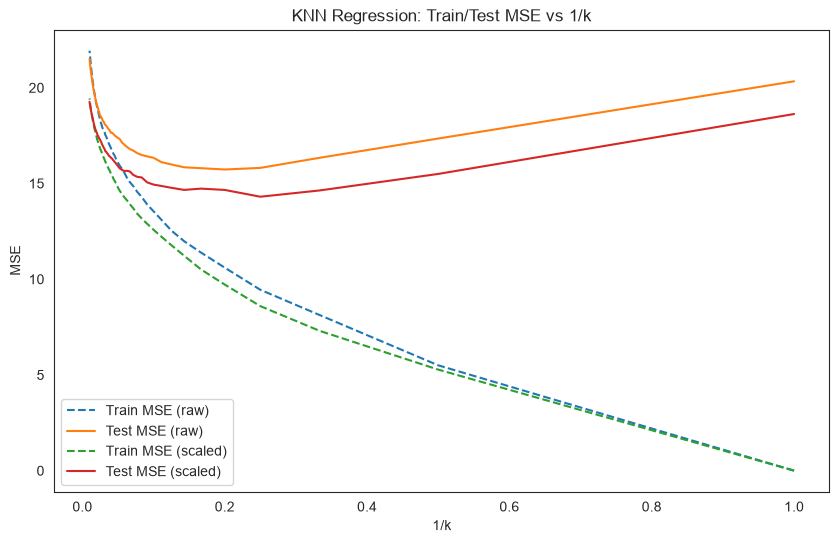

In [25]:
inv_k = 1 / np.array(k_values)

plt.figure(figsize=(10, 6))
plt.plot(inv_k, train_mse_raw, label='Train MSE (raw)', linestyle='--')
plt.plot(inv_k, test_mse_raw, label='Test MSE (raw)')
plt.plot(inv_k, train_mse_scaled, label='Train MSE (scaled)', linestyle='--')
plt.plot(inv_k, test_mse_scaled, label='Test MSE (scaled)')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression: Train/Test MSE vs 1/k')
plt.legend()
plt.show()

### (j ) Compare KNN and Linear

#### **Comparison: KNN vs Best Linear Regression Model**

| Model | Test MSE |
|---|---|
| Best linear model (Model 2, with interactions & quadratic terms) | 18.69 |
| Best KNN model (k=4, scaled features) | 14.31 |

KNN regression outperforms the best linear regression model by 
approximately 23% in test MSE. This suggests that the true relationship 
between the predictors and PE may involve nonlinear patterns or 
interactions more complex than what a quadratic-with-interactions 
specification can capture — KNN, as a non-parametric method, can adapt 
to arbitrary local structure in the data without assuming any specific 
functional form.

However, this predictive advantage comes with tradeoffs. KNN offers no 
interpretable coefficients — it cannot answer questions like "how much 
does PE change per degree increase in AT," which the linear model can. 
KNN also requires storing the entire training set and computing distances 
at prediction time, making it computationally more expensive to deploy 
at scale, and its performance can degrade in higher-dimensional settings 
due to the curse of dimensionality — a concern less relevant here given 
only four predictors, but worth noting as a general limitation.

In summary, if the primary goal is predictive accuracy, KNN is the 
stronger choice for this dataset. If interpretability of the relationship 
between environmental conditions and power output is also a priority, 
the linear model remains valuable despite its higher error.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

**n large, p small → Flexible is better.**

A large sample size provides enough data for a flexible method to learn 
fine-grained patterns without overfitting (since noise tends to average 
out as n grows). A small p also means the method is less exposed to the 
curse of dimensionality, allowing flexible methods to safely take 
advantage of their higher capacity.


### (b) The number of predictors p is extremely large, and the number of observations n is small.

**p large, n small → Inflexible is better.**

With many predictors and few observations, a flexible method has too much 
capacity relative to the available data and is highly prone to overfitting 
— it can effectively "memorize" noise in the small training set. An 
inflexible method, with fewer parameters, is far less sensitive to this 
and provides more stable estimates.

### (c) The relationship between the predictors and response is highly non-linear.

**Relationship is highly non-linear → Flexible is better.**

An inflexible method (e.g., linear regression) assumes an overly simple 
functional form and cannot capture curved relationships, leading to high 
bias. A flexible method has enough degrees of freedom to approximate the 
true non-linear shape more closely.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

**Error variance σ² is extremely high → Inflexible is better.**

When the noise in the data is very large, a flexible method is likely to 
fit that noise directly (overfitting), since it has enough capacity to 
chase every fluctuation in the training data. An inflexible method, being 
more rigid, is less affected by random noise and produces more stable 
predictions.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

**Euclidean distances from each observation to the test point (0,0,0):**

| Obs. | X1 | X2 | X3 | Distance |
|---|---|---|---|---|
| 1 | 0 | 3 | 0 | 3 |
| 2 | 2 | 0 | 0 | 2 |
| 3 | 0 | 1 | 3 | √10 |
| 4 | 0 | 1 | 2 | √5 |
| 5 | -1 | 0 | 1 | √2 |
| 6 | 1 | 1 | 1 | √3 |

### (b) What is our prediction with K = 1? Why?

**Prediction with K = 1:Green**

The single closest observation is Obs. 5 (distance = √2), which has 
Y = Green. Therefore, our prediction is **Green**.

### (c) What is our prediction with K = 3? Why?

**Prediction with K = 3: Red**

The three closest observations are Obs. 5 (√2, Green), Obs. 6 (√3, Red), 
and Obs. 2 (2, Red). Among these, Red appears twice and Green appears 
once. By majority vote, our prediction is **Red**.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

**we would expect the best value for k to be small**

 A small K allows the 
decision boundary to be more flexible and locally sensitive, since 
predictions are based on only a few nearby points. A large K, by 
contrast, averages over more neighbors and produces a smoother, less 
flexible boundary. Since a highly non-linear Bayes decision boundary 
requires a method capable of capturing complex local structure, a 
smaller K is better suited to approximate it.